<!-- Analyzed Zomato restaurant dataset using Python’s Pandas, Seaborn, and Matplotlib. Built full-scale visualizations including heatmaps, ratings-vs-votes scatter, cuisine trends (WordCloud), and delivery availability insights. -->

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("cleaned_zomato.csv")
df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes,country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,True,False,False,False,3,4.8,Dark Green,Excellent,314,Philippines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,True,False,False,False,3,4.5,Dark Green,Excellent,591,Philippines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,True,False,False,False,4,4.4,Green,Very Good,270,Philippines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,False,False,False,False,4,4.9,Dark Green,Excellent,365,Philippines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,True,False,False,False,4,4.8,Dark Green,Excellent,229,Philippines


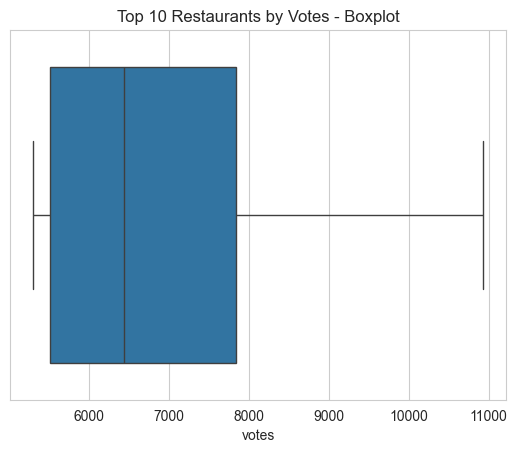

In [4]:
top10_votes = df.sort_values(by='votes', ascending=False).head(10)

sns.boxplot(x=top10_votes['votes'])
plt.title("Top 10 Restaurants by Votes - Boxplot")
plt.show()



In [5]:
import warnings
warnings.filterwarnings('ignore')

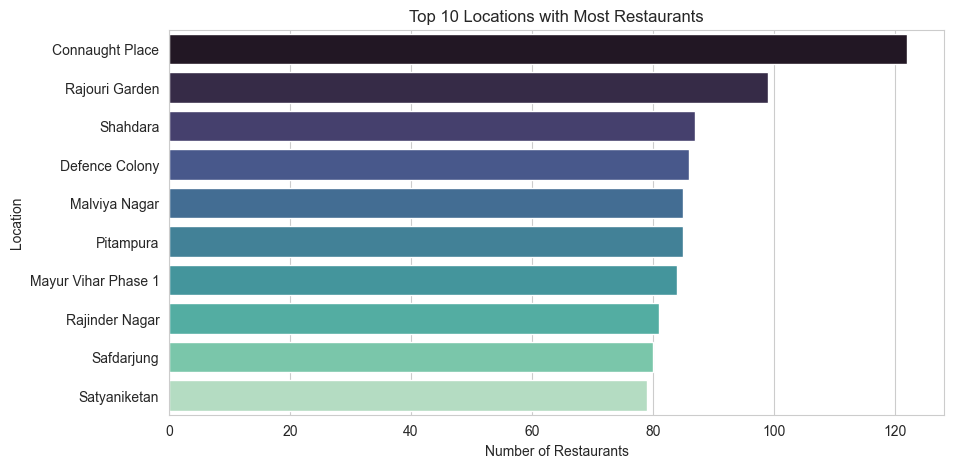

In [6]:
top_locations = df['locality'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, y=top_locations.index, palette="mako")
plt.title("Top 10 Locations with Most Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()


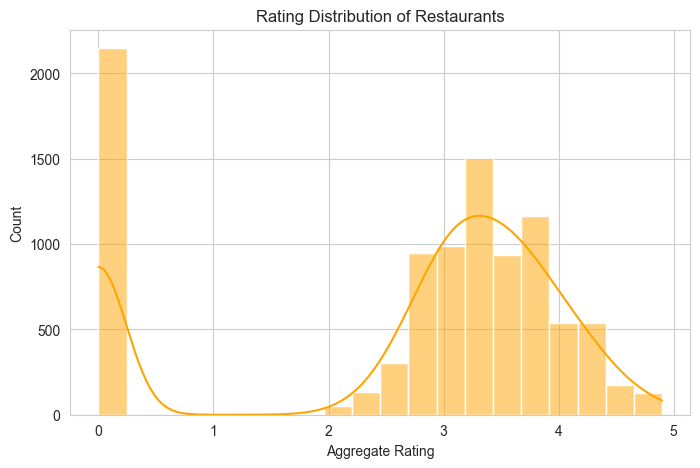

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['aggregate_rating'], bins=20, kde=True, color="orange")
plt.title("Rating Distribution of Restaurants")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")
plt.show()


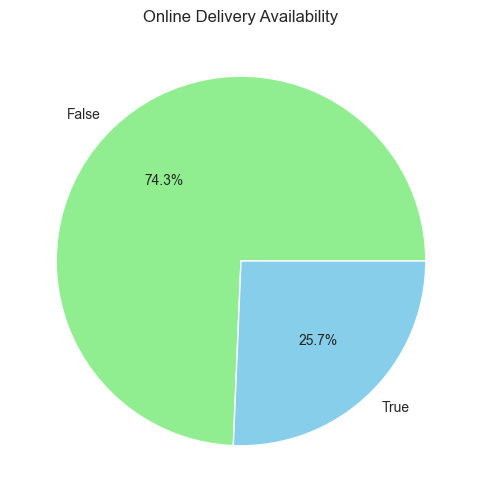

In [8]:
plt.figure(figsize=(6,6))
df['has_online_delivery'].value_counts().plot.pie(autopct='%1.1f%%', colors=["lightgreen", "skyblue"])
plt.title("Online Delivery Availability")
plt.ylabel("")
plt.show()

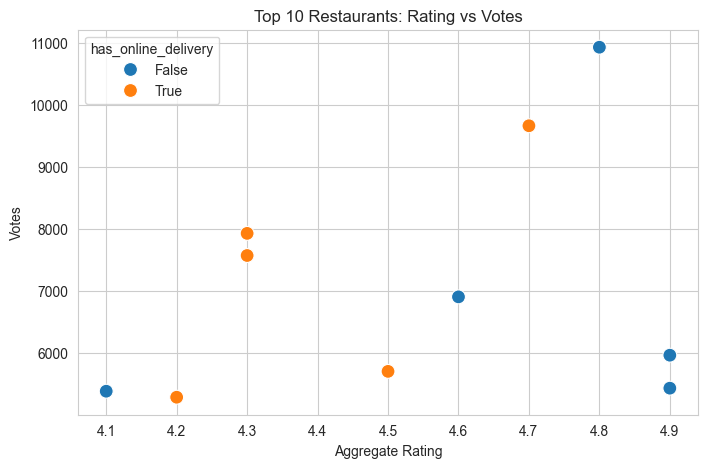

In [9]:
top10 = df.sort_values(by='votes', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.scatterplot(x='aggregate_rating', y='votes', data=top10, hue='has_online_delivery', s=100)
plt.title("Top 10 Restaurants: Rating vs Votes")
plt.xlabel("Aggregate Rating")
plt.ylabel("Votes")
plt.show()



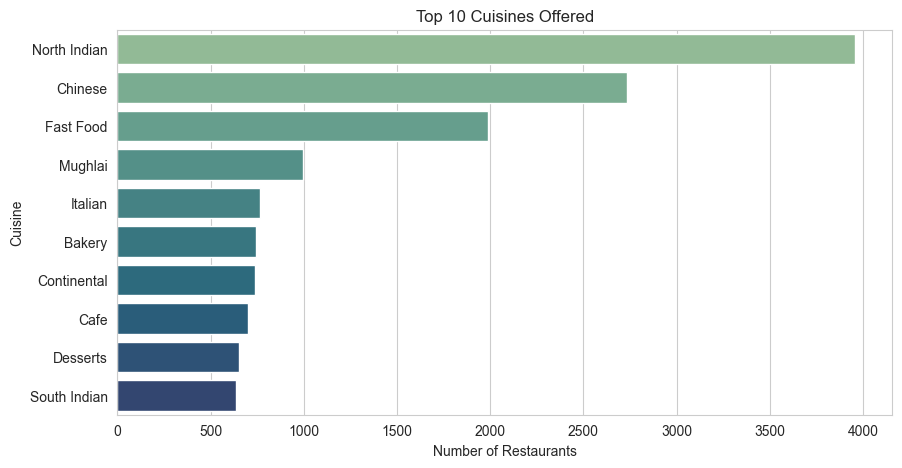

In [10]:
from collections import Counter

cuisines = df['cuisines'].dropna().apply(lambda x: x.split(', '))
flat_cuisines = [item.strip() for sublist in cuisines for item in sublist]
top_cuisines = pd.Series(flat_cuisines).value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="crest")
plt.title("Top 10 Cuisines Offered")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()



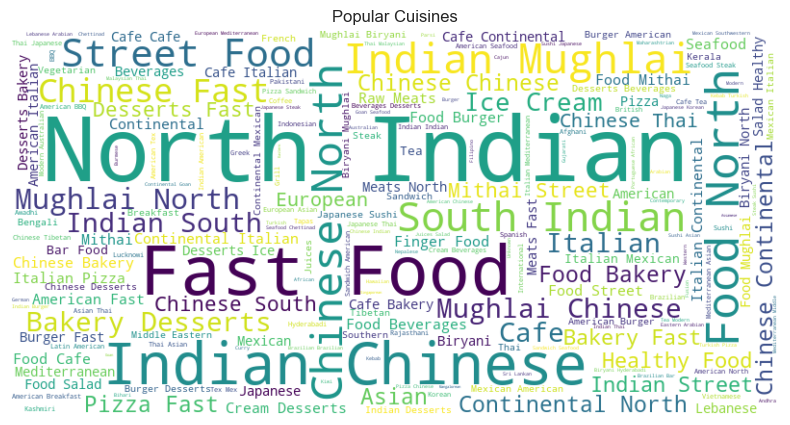

In [11]:
from wordcloud import WordCloud

text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisines")
plt.show()


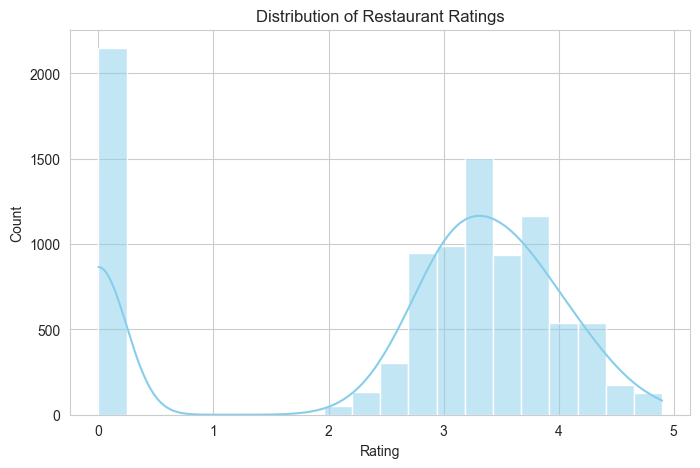

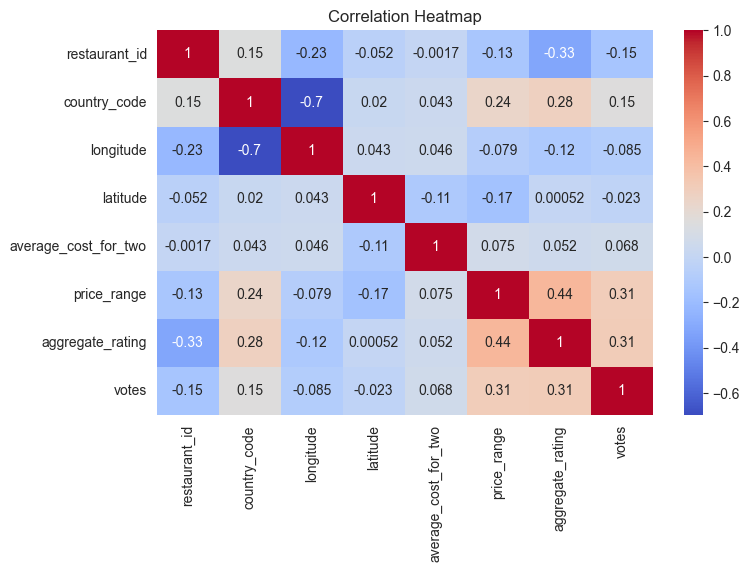

In [13]:
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include='number')  # सिर्फ numeric columns निकालना
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

